# Testing notebook for Adjusted Gradient Descent (AGD)

- You can use this notebook to test your `agd` function in Q2 on a polynomial regression.
- Just copy your `agd` function into the 2nd cell below, and run all cells. The last cell should produce the results similar to those shown currently.
- You don't need to submit this notebook, and it will not be marked.


In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
######### Copy your agd function here ################


converged in 428 iterations
Θ*: [ 19.40119048 -13.4687562  -11.35241597  17.11317055]
Θs: [ 19.38067188 -13.46827914 -11.36100414  17.11250533]


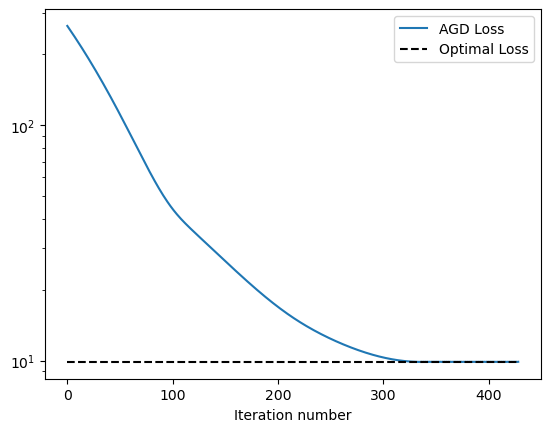

In [3]:
y = np.array([[8.4,11.1,12.7,15.3,19,21.7,25.9,26.4,20.3,17.9,12.8,7.2,8.4,10.4,10.6,13.7]]).T
x = np.linspace(-1,1,y.size)

def features(x,n):
    powers = np.arange(n+1)                
    powers = np.reshape(powers, (1, -1))   
    x = np.reshape(x, (-1, 1))             
    return x**powers                       
                                           
def optimise_loss(V,y):
    return np.linalg.solve(V.T @ V, V.T @ y)

def loss(Xh, Theta, Y):
    return np.mean((Xh @ Theta - Y)**2)

def grad_loss(Xh, Theta, Y):
    return 2 * Xh.T @ (Xh @ Theta - Y) / Xh.shape[0]


# Test the optimal Theta* and the agd function
n = 3
Xh = features(x, n)
Theta_star = optimise_loss(Xh, y)

# Use all data for both training and testing in this simple example
Theta_agd, k_star, losses = agd(Xh, y, Xh, y, np.zeros((n+1,1)), t=1/16)

# Compare Thetas and losses
print("Θ*:", Theta_star.flatten())
print("Θs:", Theta_agd.flatten())
plt.semilogy(losses, label='AGD Loss')
plt.semilogy([loss(Xh, Theta_star, y)]*len(losses), 'k--', label='Optimal Loss')
plt.xlabel('Iteration number')
plt.legend()
plt.show()
